In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_excel('data/raw/Online Retail.xlsx')
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [4]:
duplicate_value = df.duplicated().sum()
duplicate_value

5268

In [5]:
df = df.drop_duplicates()
duplicate_values_after = df.duplicated().sum()

In [6]:
print(f"Number of duplicate values after dropping duplicates: {duplicate_values_after}")

Number of duplicate values after dropping duplicates: 0


In [7]:
missing_values = df.isnull().sum()
missing_values

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [8]:
df['Description'] = df['Description'].fillna("Unknow")

In [9]:
df = df.dropna(subset=['CustomerID'])

In [10]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.7+ MB


In [12]:
invoiceno_values = df['InvoiceNo'].value_counts()
invoiceno_values

InvoiceNo
576339     542
579196     533
580727     529
578270     442
573576     435
          ... 
581487       1
581491       1
C581499      1
581566       1
C581568      1
Name: count, Length: 22190, dtype: int64

In [13]:
# Tạo cột phân loại: 'Canceled' nếu chứa 'C', ngược lại là 'Normal'
df['Order_Type'] = df['InvoiceNo'].apply(lambda x: 'Canceled' if str(x).startswith('C') else 'Normal')

# Kiểm tra số lượng
print(df['Order_Type'].value_counts())

Order_Type
Normal      392732
Canceled      8872
Name: count, dtype: int64


C:\Users\NGUYEN\AppData\Local\Temp\ipykernel_7908\2074439174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Order_Type', palette={'Normal': 'skyblue', 'Canceled': 'salmon'})


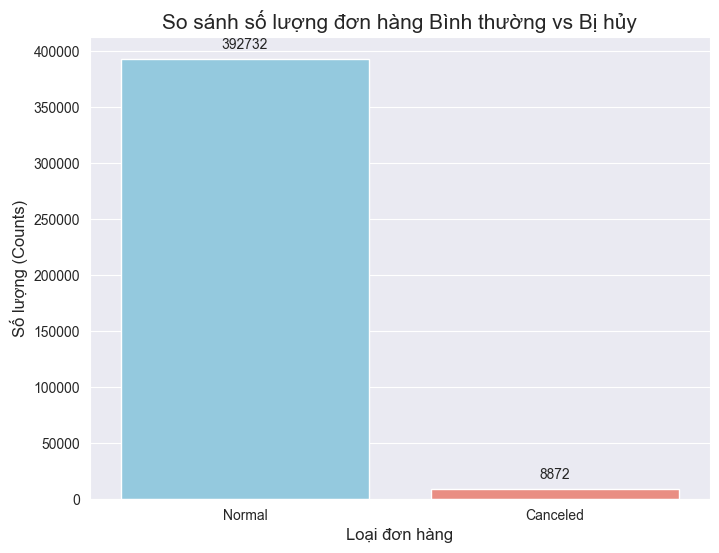

In [14]:
plt.figure(figsize=(8, 6))
sns.set_style("darkgrid")

# Vẽ biểu đồ countplot
ax = sns.countplot(data=df, x='Order_Type', palette={'Normal': 'skyblue', 'Canceled': 'salmon'})

# Thêm tiêu đề và nhãn
plt.title('So sánh số lượng đơn hàng Bình thường vs Bị hủy', fontsize=15)
plt.xlabel('Loại đơn hàng', fontsize=12)
plt.ylabel('Số lượng (Counts)', fontsize=12)

# Hiển thị số liệu cụ thể trên đầu cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

plt.show()

***Variable Quantity***

In [15]:
# Tạo cột phân loại dựa trên giá trị Quantity
df['Quantity_Type'] = df['Quantity'].apply(lambda x: 'Negative (Return)' if x < 0 else 'Positive (Sale)')

# Thống kê số lượng mỗi loại
status_counts = df['Quantity_Type'].value_counts()
print(status_counts)

Quantity_Type
Positive (Sale)      392732
Negative (Return)      8872
Name: count, dtype: int64


C:\Users\NGUYEN\AppData\Local\Temp\ipykernel_7908\1869332656.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Quantity_Type', palette=palette)


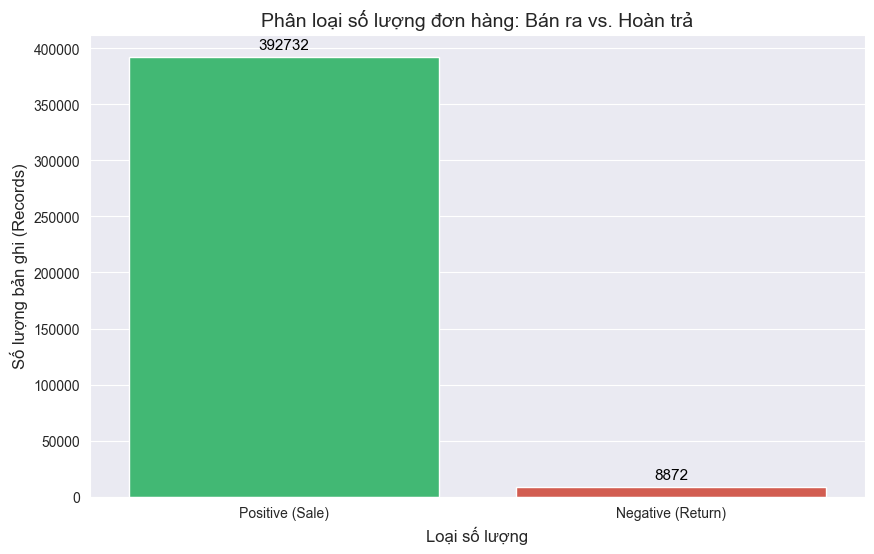

In [16]:
plt.figure(figsize=(10, 6))
# Sử dụng bảng màu tương phản: Đỏ cho giá trị âm, Xanh cho giá trị dương
palette = {'Negative (Return)': '#e74c3c', 'Positive (Sale)': '#2ecc71'}

ax = sns.countplot(data=df, x='Quantity_Type', palette=palette)

plt.title('Phân loại số lượng đơn hàng: Bán ra vs. Hoàn trả', fontsize=14)
plt.xlabel('Loại số lượng', fontsize=12)
plt.ylabel('Số lượng bản ghi (Records)', fontsize=12)

# Chèn số liệu lên đầu cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

***Variable UnitPrice***

In [17]:
def classify_price(price):
    if price < 0:
        return 'Negative (Adjustment)'
    elif price == 0:
        return 'Zero (Free/Gift)'
    else:
        return 'Positive (Normal Sale)'

# Áp dụng phân loại
df['Price_Type'] = df['UnitPrice'].apply(classify_price)

# Thống kê nhanh
print(df['Price_Type'].value_counts())

Price_Type
Positive (Normal Sale)    401564
Zero (Free/Gift)              40
Name: count, dtype: int64


C:\Users\NGUYEN\AppData\Local\Temp\ipykernel_7908\853219849.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Price_Type', palette=['#e74c3c', '#f1c40f', '#2ecc71'])
C:\Users\NGUYEN\AppData\Local\Temp\ipykernel_7908\853219849.py:5: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.countplot(data=df, x='Price_Type', palette=['#e74c3c', '#f1c40f', '#2ecc71'])


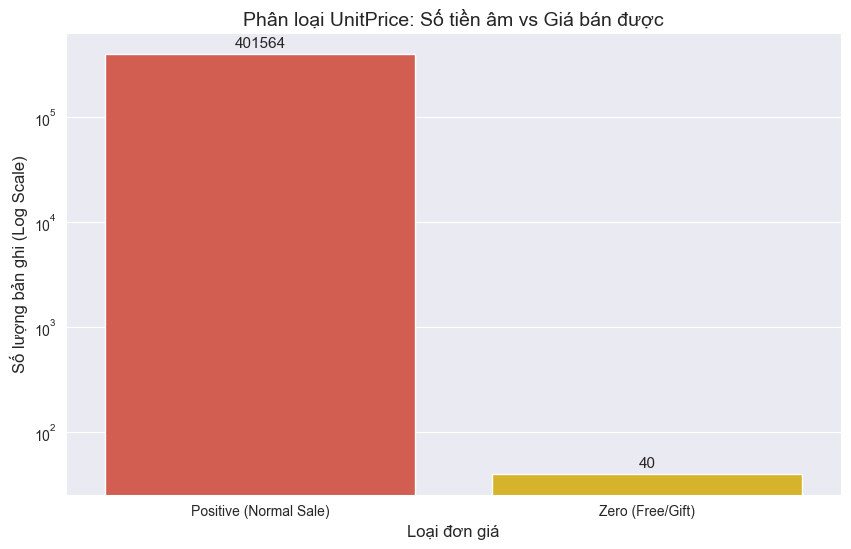

In [18]:
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")

# Vẽ countplot
ax = sns.countplot(data=df, x='Price_Type', palette=['#e74c3c', '#f1c40f', '#2ecc71'])

# Chỉnh tiêu đề
plt.title('Phân loại UnitPrice: Số tiền âm vs Giá bán được', fontsize=14)
plt.xlabel('Loại đơn giá', fontsize=12)
plt.ylabel('Số lượng bản ghi (Log Scale)', fontsize=12)

# Sử dụng Log Scale để có thể nhìn thấy các nhóm có số lượng cực ít
ax.set_yscale("log") 

# Hiển thị số lượng thực tế trên đầu cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.show()

In [19]:
# Remove invalid quantities
df = df[df['Quantity'] > 0]

In [20]:
# Remove canceled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   InvoiceNo      392732 non-null  object        
 1   StockCode      392732 non-null  object        
 2   Description    392732 non-null  object        
 3   Quantity       392732 non-null  int64         
 4   InvoiceDate    392732 non-null  datetime64[us]
 5   UnitPrice      392732 non-null  float64       
 6   CustomerID     392732 non-null  float64       
 7   Country        392732 non-null  str           
 8   Order_Type     392732 non-null  str           
 9   Quantity_Type  392732 non-null  str           
 10  Price_Type     392732 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(4)
memory usage: 57.2+ MB


In [32]:
# Convert to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [33]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.month_name()
df['Day'] = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

In [34]:
df['YearMonth'] = df['InvoiceDate'].dt.strftime('%Y-%m')

In [38]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   InvoiceNo      392732 non-null  object        
 1   StockCode      392732 non-null  object        
 2   Description    392732 non-null  object        
 3   Quantity       392732 non-null  int64         
 4   InvoiceDate    392732 non-null  datetime64[us]
 5   UnitPrice      392732 non-null  float64       
 6   CustomerID     392732 non-null  float64       
 7   Country        392732 non-null  str           
 8   Order_Type     392732 non-null  str           
 9   Quantity_Type  392732 non-null  str           
 10  Price_Type     392732 non-null  str           
 11  Year           392732 non-null  int32         
 12  Month          392732 non-null  int32         
 13  MonthName      392732 non-null  str           
 14  Day            392732 non-null  int32         
 15  Weekday        3

In [40]:
df.duplicated().sum()

0

In [41]:
df.isnull().sum()

InvoiceNo        0
StockCode        0
Description      0
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID       0
Country          0
Order_Type       0
Quantity_Type    0
Price_Type       0
Year             0
Month            0
MonthName        0
Day              0
Weekday          0
Hour             0
YearMonth        0
Revenue          0
dtype: int64

In [42]:
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

In [44]:
df['YearMonth'] = pd.to_datetime(df['YearMonth'])

In [45]:
df.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   InvoiceNo      392732 non-null  object        
 1   StockCode      392732 non-null  object        
 2   Description    392732 non-null  object        
 3   Quantity       392732 non-null  int64         
 4   InvoiceDate    392732 non-null  datetime64[us]
 5   UnitPrice      392732 non-null  float64       
 6   CustomerID     392732 non-null  str           
 7   Country        392732 non-null  str           
 8   Order_Type     392732 non-null  str           
 9   Quantity_Type  392732 non-null  str           
 10  Price_Type     392732 non-null  str           
 11  Year           392732 non-null  int32         
 12  Month          392732 non-null  int32         
 13  MonthName      392732 non-null  str           
 14  Day            392732 non-null  int32         
 15  Weekday        3

***Check outliers***

In [46]:
df[['Quantity', 'UnitPrice', 'Revenue']].describe()

,Quantity,UnitPrice,Revenue
count,392732.000000,392732.000000,392732.000000
mean,13.153718,3.125596,22.629195
std,181.588420,22.240725,311.083465
min,1.000000,0.000000,0.000000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.390000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [49]:
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

revenue_outliers = df[
    (df['Revenue'] < lower) |
    (df['Revenue'] > upper)
]

print(revenue_outliers.shape)

(31231, 19)


In [50]:
print(revenue_outliers[revenue_outliers['Revenue'] > 0].shape) # Đơn hàng sỉ
print(revenue_outliers[revenue_outliers['Revenue'] < 0].shape) # Đơn hàng hủy/lỗi

(31231, 19)
(0, 19)


In [51]:
cols_to_keep = [
    'InvoiceNo', 'StockCode', 'Description', 'Quantity', 
    'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 
    'Revenue', 'Year', 'Month', 'MonthName', 'Day', 
    'Weekday', 'Hour', 'YearMonth'
]

# Tạo dataframe mới chỉ chứa các cột cần thiết
df_final = df[cols_to_keep]

In [53]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[us]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  str           
 7   Country      392732 non-null  str           
 8   Revenue      392732 non-null  float64       
 9   Year         392732 non-null  int32         
 10  Month        392732 non-null  int32         
 11  MonthName    392732 non-null  str           
 12  Day          392732 non-null  int32         
 13  Weekday      392732 non-null  str           
 14  Hour         392732 non-null  int32         
 15  YearMonth    392732 non-null  datetime64[us]
dtype

In [54]:
# Lưu file
file_name = 'data/processed/online_retail_cleaned_final.csv'

df_final.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"Đã lưu thành công file: {file_name}")
print(f"Kích thước file mới: {df_final.shape}")

Đã lưu thành công file: data/processed/online_retail_cleaned_final.csv
Kích thước file mới: (392732, 16)
